# 🏦 Customer Cashflow Forecasting Engine

## 🎯 Project Objective
Build an end-to-end machine learning pipeline that forecasts a customer’s next-period account balance using transaction history, income and expense behavior, and financial obligation patterns.

This portfolio project highlights:
- data ingestion and preprocessing for banking transaction records
- feature engineering for cashflow, recurring income, and loan payments
- supervised learning to predict future balance outcomes
- business impact in risk management, customer retention, and proactive banking services


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error   

In [2]:
df  = pd.read_csv('balance_forecasting_persona.csv')

In [3]:
df.shape

(120000, 9)

In [4]:
df.head()

,customer_id,persona,month,salary,other_credit,total_credit,total_debit,emi,balance
0,1,overspender,1,31158.88,2229.16,33388.04,58844.07,6772,17701.97
1,1,overspender,2,30346.82,714.33,31061.16,38441.90,6772,10321.23
2,1,overspender,3,29491.09,3609.99,33101.08,40521.80,6772,2900.51
3,1,overspender,4,29319.40,4961.06,34280.46,41724.30,6772,-4543.32
4,1,overspender,5,31204.56,35.33,31239.89,56537.38,6772,-29840.81


In [5]:
# Extracting expense by subtracting EMI from total debit
df['expense'] = df['total_debit'] - df['emi']

In [6]:
# Dropping total_debit as it is the sum of expense and emi, and total_credit as it is sum of salary and other_credit
df= df.drop(columns=['total_debit', 'total_credit'], axis=1)

In [7]:
df.head()

,customer_id,persona,month,salary,other_credit,emi,balance,expense
0,1,overspender,1,31158.88,2229.16,6772,17701.97,52072.07
1,1,overspender,2,30346.82,714.33,6772,10321.23,31669.90
2,1,overspender,3,29491.09,3609.99,6772,2900.51,33749.80
3,1,overspender,4,29319.40,4961.06,6772,-4543.32,34952.30
4,1,overspender,5,31204.56,35.33,6772,-29840.81,49765.38


## Enriching the dataset with lag features

In [8]:
df = df.sort_values(["customer_id", "month"])

df["prev_balance"] = df.groupby("customer_id")["balance"].shift(1)
df["prev_expense"] = df.groupby("customer_id")["expense"].shift(1)
df["prev_emi"] = df.groupby("customer_id")["emi"].shift(1)
df["prev_salary"] = df.groupby("customer_id")["salary"].shift(1)
df["prev_other_credit"] = df.groupby("customer_id")["other_credit"].shift(1)


df["target_next_balance"] = df.groupby("customer_id")["balance"].shift(-1)

df = df.dropna()


In [9]:
df.head()

,customer_id,persona,month,salary,other_credit,emi,balance,expense,prev_balance,prev_expense,prev_emi,prev_salary,prev_other_credit,target_next_balance
1,1,overspender,2,30346.82,714.33,6772,10321.23,31669.90,17701.97,52072.07,6772.0,31158.88,2229.16,2900.51
2,1,overspender,3,29491.09,3609.99,6772,2900.51,33749.80,10321.23,31669.90,6772.0,30346.82,714.33,-4543.32
3,1,overspender,4,29319.40,4961.06,6772,-4543.32,34952.30,2900.51,33749.80,6772.0,29491.09,3609.99,-29840.81
4,1,overspender,5,31204.56,35.33,6772,-29840.81,49765.38,-4543.32,34952.30,6772.0,29319.40,4961.06,-37216.12
5,1,overspender,6,30550.97,233.33,6772,-37216.12,31387.62,-29840.81,49765.38,6772.0,31204.56,35.33,-44585.64


In [10]:
df.shape

(110000, 14)

In [11]:
# Encoding customer_id as categorical codes
df['customer_id'] = df['customer_id'].astype('category')

# Extracting month of year from month column
df["month_of_year"] = ((df["month"] - 1) % 12) + 1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110000 entries, 1 to 119998
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   customer_id          110000 non-null  category
 1   persona              110000 non-null  object  
 2   month                110000 non-null  int64   
 3   salary               110000 non-null  float64 
 4   other_credit         110000 non-null  float64 
 5   emi                  110000 non-null  int64   
 6   balance              110000 non-null  float64 
 7   expense              110000 non-null  float64 
 8   prev_balance         110000 non-null  float64 
 9   prev_expense         110000 non-null  float64 
 10  prev_emi             110000 non-null  float64 
 11  prev_salary          110000 non-null  float64 
 12  prev_other_credit    110000 non-null  float64 
 13  target_next_balance  110000 non-null  float64 
 14  month_of_year        110000 non-null  int64   
dtypes: ca

## EDA

Explore data quality, target behavior, time trends, persona differences, and feature relationships before building the forecasting models.

In [13]:
# Dataset overview and data quality checks
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0])

money_cols = ["salary", "other_credit", "emi", "expense", "balance", "target_next_balance"]
df[money_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


Dataset shape: (110000, 15)
Duplicate rows: 0


Series([], dtype: int64)

,count,mean,std,min,1%,5%,50%,95%,99%,max
salary,110000.0,92075.037292,35958.244351,15579.68,31343.9421,36397.6635,91702.790,1.482002e+05,1.568347e+05,165143.78
other_credit,110000.0,2503.319853,1440.364563,0.02,49.3493,254.7575,2507.710,4.748245e+03,4.950610e+03,4999.99
emi,110000.0,7013.703200,5484.442900,6.00,227.9600,929.9000,5407.000,2.009615e+04,2.404317e+04,24995.00
expense,110000.0,69795.873769,39002.829397,8851.97,15965.8363,22451.8820,62265.515,1.429275e+05,1.976748e+05,444426.53
balance,110000.0,269815.113833,381049.121297,-1301199.30,-469987.6144,-211320.0105,183530.645,1.024526e+06,1.497530e+06,2286925.26
target_next_balance,110000.0,287715.783461,403391.962219,-1417261.50,-504649.0762,-230240.6150,205421.760,1.080178e+06,1.567757e+06,2397434.52


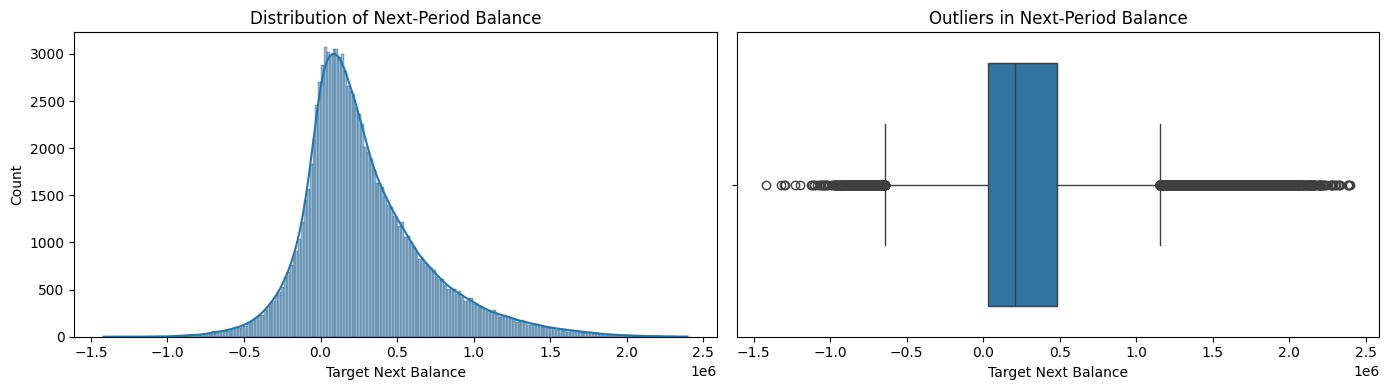

Target skewness: 1.01


In [14]:
# Target distribution and outlier check
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["target_next_balance"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Next-Period Balance")
axes[0].set_xlabel("Target Next Balance")

sns.boxplot(x=df["target_next_balance"], ax=axes[1])
axes[1].set_title("Outliers in Next-Period Balance")
axes[1].set_xlabel("Target Next Balance")

plt.tight_layout()
plt.show()

print(f"Target skewness: {df['target_next_balance'].skew():.2f}")


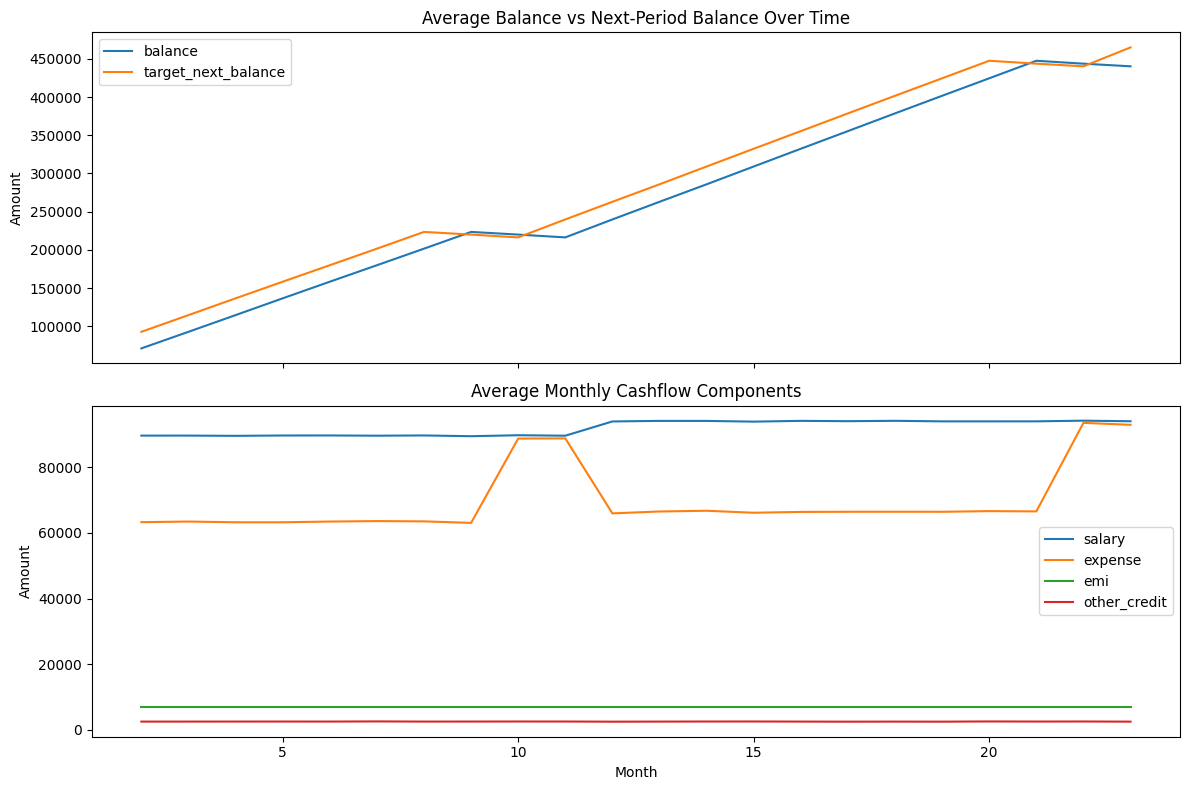

In [15]:
# Time trends for balance and cashflow components
monthly_summary = df.groupby("month")[[
    "balance", "target_next_balance", "salary", "expense", "emi", "other_credit"
]].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
monthly_summary[["balance", "target_next_balance"]].plot(ax=axes[0])
axes[0].set_title("Average Balance vs Next-Period Balance Over Time")
axes[0].set_ylabel("Amount")

monthly_summary[["salary", "expense", "emi", "other_credit"]].plot(ax=axes[1])
axes[1].set_title("Average Monthly Cashflow Components")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Amount")

plt.tight_layout()
plt.show()


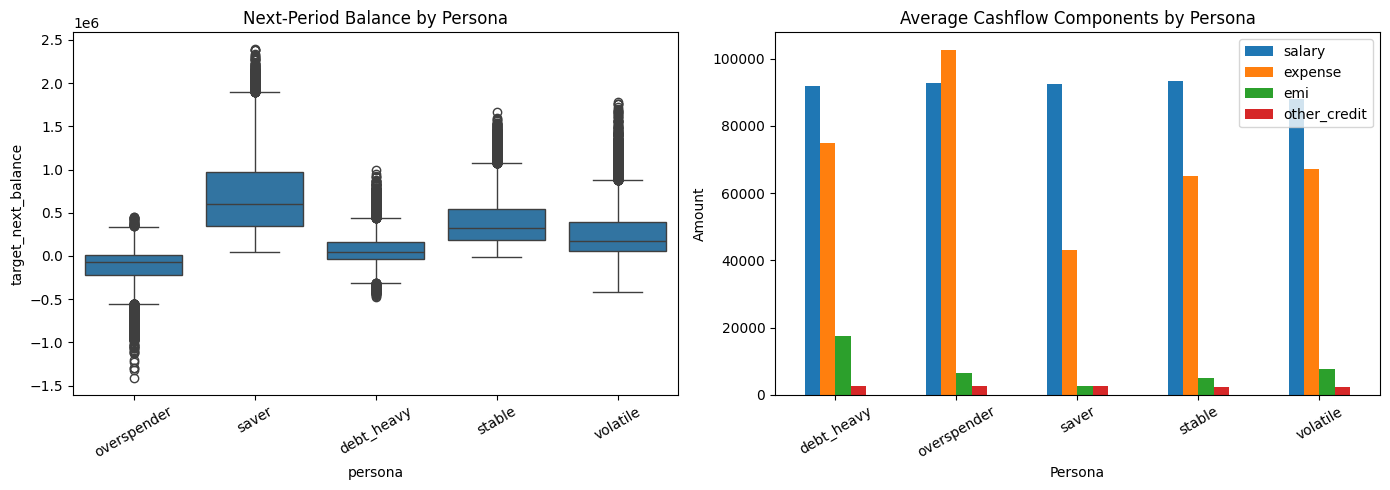

In [16]:
# Persona-level differences in target balance and cashflow behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="persona", y="target_next_balance", ax=axes[0])
axes[0].set_title("Next-Period Balance by Persona")
axes[0].tick_params(axis="x", rotation=30)

persona_cashflow = df.groupby("persona")[["salary", "expense", "emi", "other_credit"]].mean()
persona_cashflow.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Cashflow Components by Persona")
axes[1].set_xlabel("Persona")
axes[1].set_ylabel("Amount")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


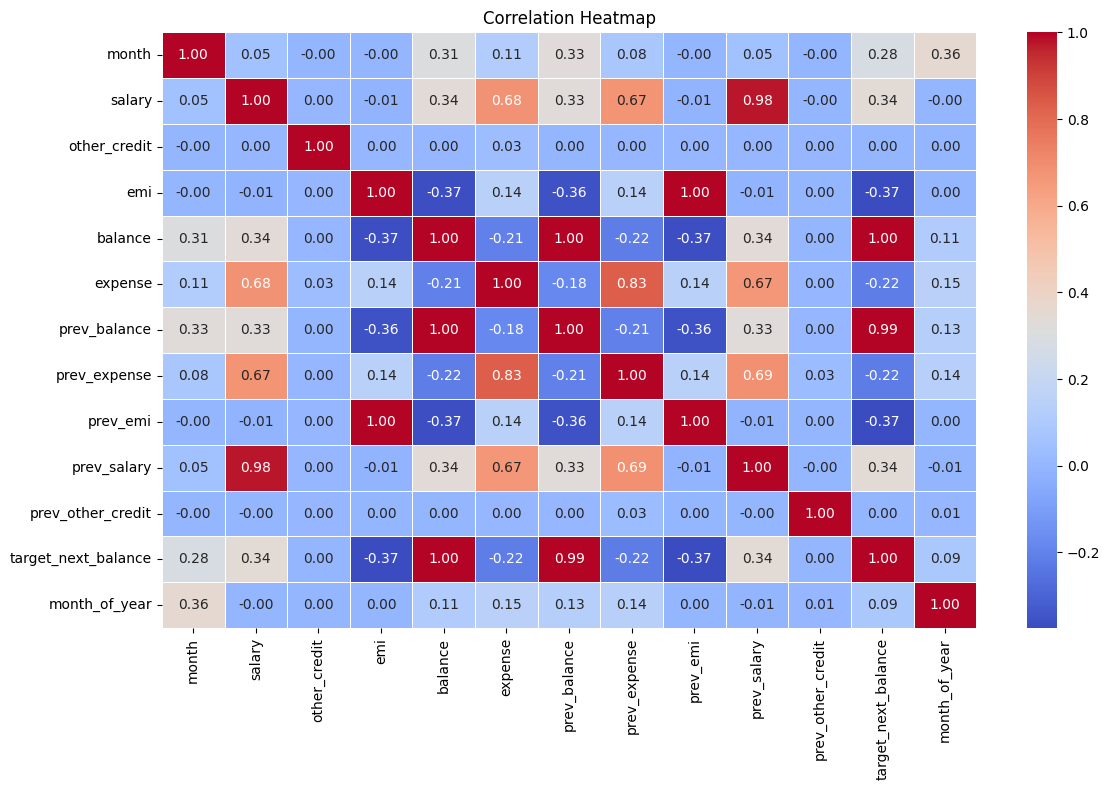

In [17]:
# Numeric feature correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


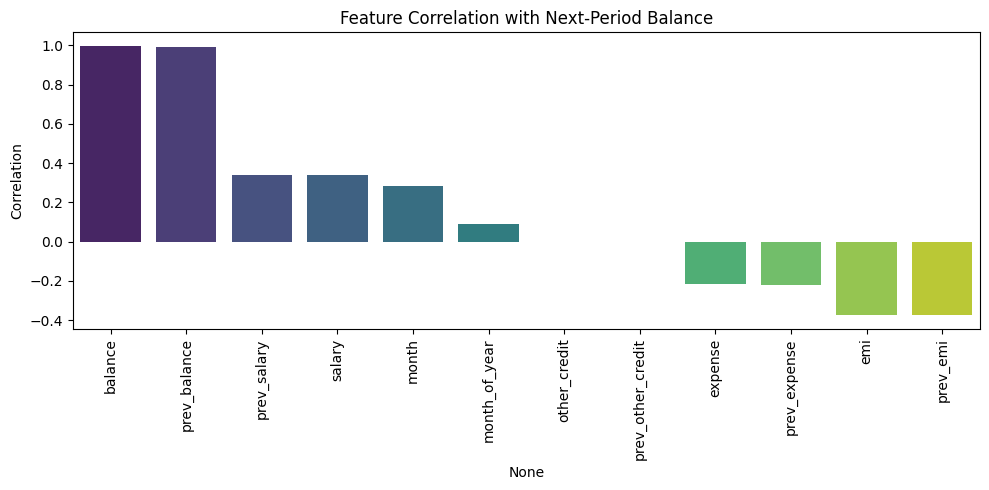

In [18]:
# Correlation of each numeric feature with the forecasting target
corr_series = df.corr(numeric_only=True)["target_next_balance"].drop("target_next_balance").sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_series.index, y=corr_series.values, hue=corr_series.index, palette="viridis", legend=False)
plt.title("Feature Correlation with Next-Period Balance")
plt.ylabel("Correlation")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


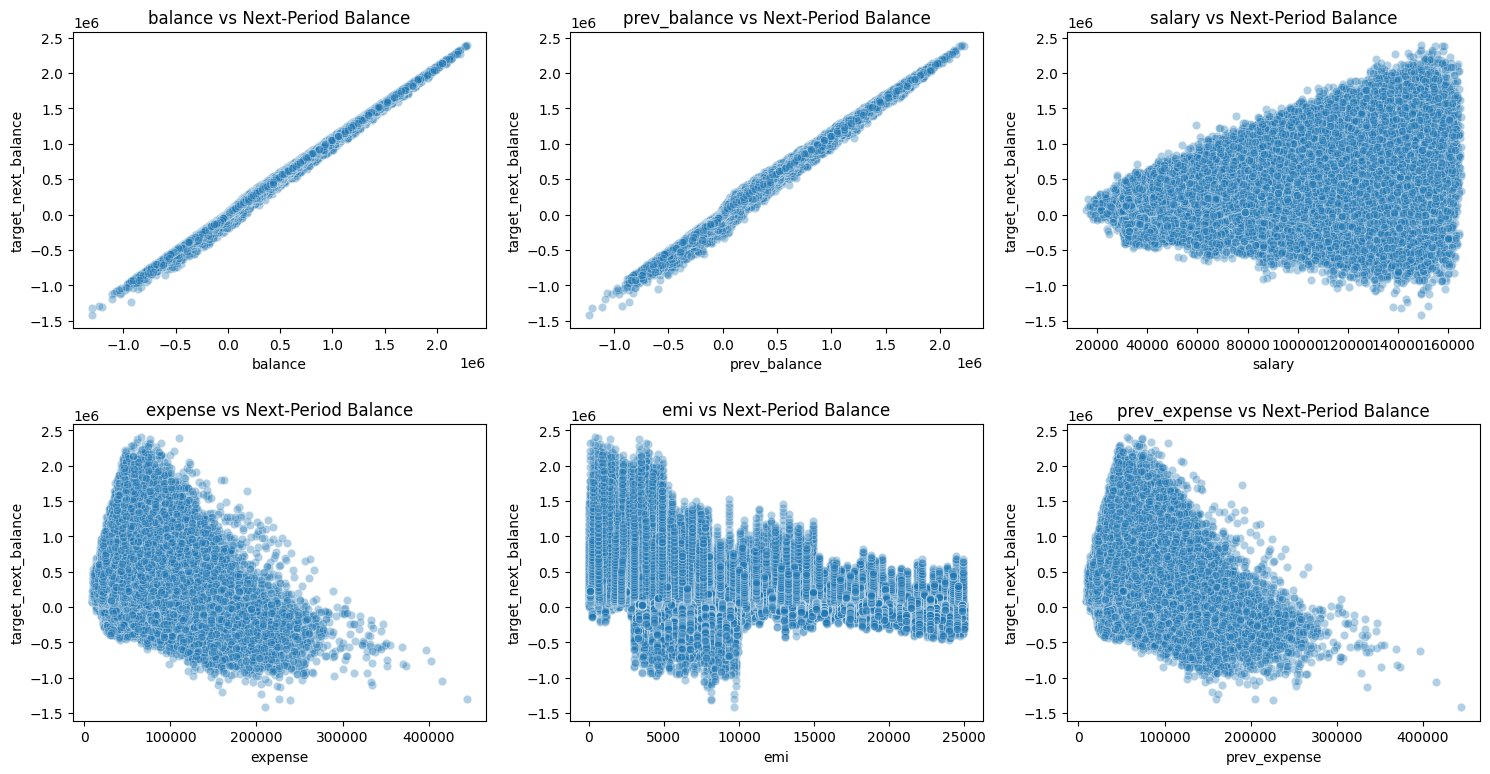

In [19]:
# Key feature relationships with the forecasting target
feature_cols = ["balance", "prev_balance", "salary", "expense", "emi", "prev_expense"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), feature_cols):
    sns.scatterplot(data=df, x=col, y="target_next_balance", alpha=0.35, ax=ax)
    ax.set_title(f"{col} vs Next-Period Balance")

plt.tight_layout()
plt.show()


In [20]:
# Keeping the target in its original scale so forecast errors remain directly interpretable.


In [21]:
# Time-based train/test split for forecasting
# Hold out complete future months so the same month is not split across train and test.
df = df.sort_values(["month", "customer_id"]).reset_index(drop=True)

X = df.drop(columns=["target_next_balance", "customer_id"], axis=1)
y = df["target_next_balance"]

train_mask = df["month"] <= 18
test_mask = df["month"] > 18

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

# Used inside GridSearchCV on the training set only.
tscv = TimeSeriesSplit(n_splits=3)

print("Train months:", X_train["month"].min(), "to", X_train["month"].max())
print("Test months:", X_test["month"].min(), "to", X_test["month"].max())
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train months: 2 to 18
Test months: 19 to 23
Train shape: (85000, 13) Test shape: (25000, 13)


In [22]:
categorical_features = ["persona"]

numeric_features = [
                    'month', 
                    'salary', 
                    'other_credit', 
                    'emi',
                    'balance', 
                    'expense', 
                    'prev_balance', 
                    'prev_expense', 
                    'prev_emi',
                    'prev_salary', 
                    'prev_other_credit',
                    'month_of_year'
                ]

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

unscaled_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


In [23]:
linear_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("model", Ridge())
])

lasso_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("model", Lasso(random_state=42, max_iter=50000, tol=1e-3))
])

elasticnet_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("model", ElasticNet(random_state=42, max_iter=50000, tol=1e-3))
])

knn_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("model", KNeighborsRegressor())
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", unscaled_preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [24]:
# use grid search to find the best hyperparameters for each model
linear_param_grid = [{}]
ridge_param_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 100.0]
}
lasso_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0]
}
elasticnet_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7],
    "model__weights": ["uniform", "distance"]
}
random_forest_param_grid = {
    "model__n_estimators": [60, 120],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [3, 5]
}

In [25]:
# Grid search for Linear Regression

linear_grid_search = GridSearchCV(estimator=linear_model, param_grid=linear_param_grid, cv=tscv)
linear_grid_search.fit(X_train, y_train)

# Grid search for Ridge Regression
ridge_grid_search = GridSearchCV(estimator=ridge_model, param_grid=ridge_param_grid, cv=tscv)
ridge_grid_search.fit(X_train, y_train)

# Grid search for Lasso Regression
lasso_grid_search = GridSearchCV(estimator=lasso_model, param_grid=lasso_param_grid, cv=tscv)
lasso_grid_search.fit(X_train, y_train)

# Grid search for Elastic Net
elasticnet_grid_search = GridSearchCV(estimator=elasticnet_model, param_grid=elasticnet_param_grid, cv=tscv)
elasticnet_grid_search.fit(X_train, y_train)

# Grid search for KNN
knn_grid_search = GridSearchCV(estimator=knn_model, param_grid=knn_param_grid, cv=tscv)
knn_grid_search.fit(X_train, y_train)

# Grid search for Random Forest
random_forest_grid_search = GridSearchCV(estimator=random_forest_model, param_grid=random_forest_param_grid, cv=tscv)
random_forest_grid_search.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20], 'model__min_samples_leaf': [3, 5], 'model__n_estimators': [60, 120]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [26]:
# Best models
best_linear = linear_grid_search.best_estimator_
best_ridge = ridge_grid_search.best_estimator_
best_lasso = lasso_grid_search.best_estimator_
best_elasticnet = elasticnet_grid_search.best_estimator_
best_knn = knn_grid_search.best_estimator_
best_random_forest = random_forest_grid_search.best_estimator_

In [27]:
# Predictions
y_pred_linear = best_linear.predict(X_test)
y_pred_ridge = best_ridge.predict(X_test)
y_pred_lasso = best_lasso.predict(X_test)
y_pred_elasticnet = best_elasticnet.predict(X_test)
y_pred_knn = best_knn.predict(X_test)
y_pred_random_forest = best_random_forest.predict(X_test)

In [28]:
# Evaluation
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2 Score: {r2:.4f}")
evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")
evaluate_model(y_test, y_pred_elasticnet, "Elastic Net")
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_random_forest, "Random Forest")

Linear Regression - MAE: 16333.4155, RMSE: 24074.9230, R2 Score: 0.9982
Ridge Regression - MAE: 16235.1835, RMSE: 24036.1434, R2 Score: 0.9983
Lasso Regression - MAE: 16346.6078, RMSE: 24073.5331, R2 Score: 0.9982
Elastic Net - MAE: 16036.7929, RMSE: 24179.9358, R2 Score: 0.9982
KNN - MAE: 48395.6964, RMSE: 67374.1962, R2 Score: 0.9863
Random Forest - MAE: 18832.2794, RMSE: 32364.5553, R2 Score: 0.9968


In [29]:
# Based on the evaluation metrics, we can select the best model for our task.
selected_model = best_random_forest


## SHAP Analysis

Explain the selected production candidate after model evaluation, using the same preprocessing pipeline that the model uses for prediction.

c:\Users\Abhishek\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


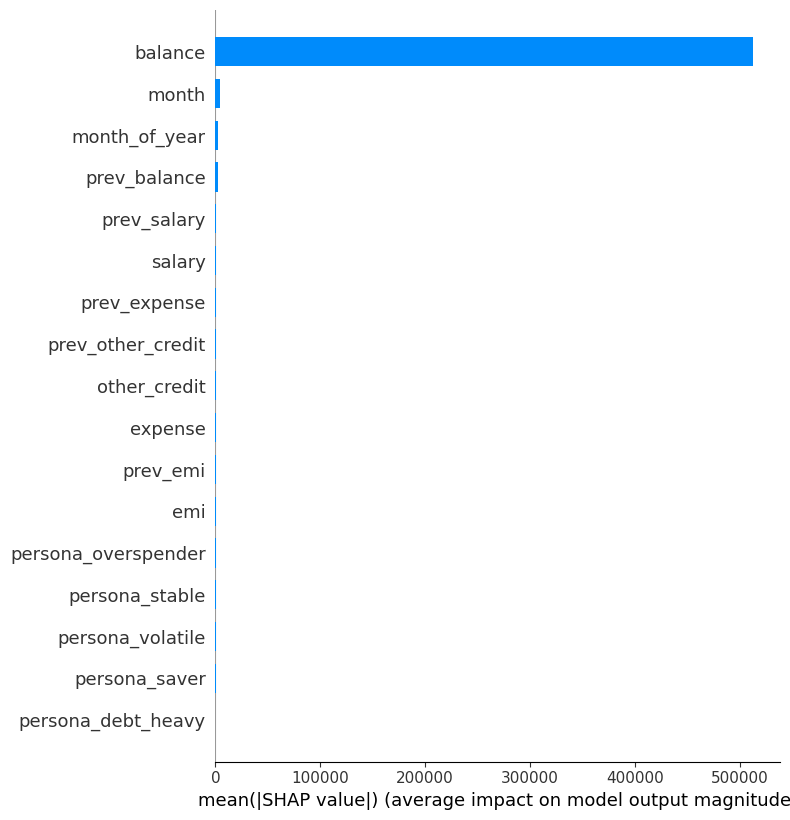

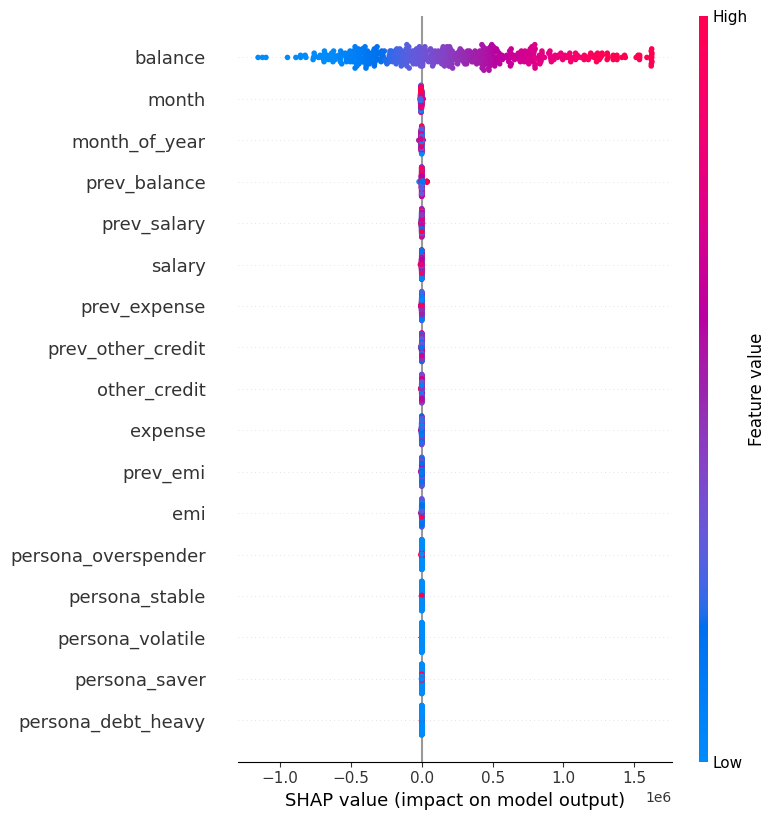

In [31]:
try:
    import shap
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("SHAP is not installed. Run `%pip install shap` in a notebook cell, then restart the kernel.") from exc

# Use a sample so SHAP remains fast and readable in the notebook.
shap_sample_size = min(500, len(X_test))
X_shap = X_test.sample(n=shap_sample_size, random_state=42) if len(X_test) > shap_sample_size else X_test.copy()

selected_preprocessor = selected_model.named_steps["preprocessor"]
selected_estimator = selected_model.named_steps["model"]

X_shap_transformed = selected_preprocessor.transform(X_shap)
feature_names = selected_preprocessor.get_feature_names_out()
feature_names = [name.replace("cat__", "").replace("num__", "") for name in feature_names]

if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

X_shap_transformed = pd.DataFrame(X_shap_transformed, columns=feature_names, index=X_shap.index)

if isinstance(selected_estimator, RandomForestRegressor):
    explainer = shap.TreeExplainer(selected_estimator)
    shap_values = explainer.shap_values(X_shap_transformed)
else:
    background = shap.sample(X_shap_transformed, min(100, len(X_shap_transformed)), random_state=42)
    explainer = shap.Explainer(selected_estimator.predict, background)
    shap_values = explainer(X_shap_transformed)

# Global feature importance: which features most influence the selected model overall.
shap.summary_plot(shap_values, X_shap_transformed, plot_type="bar")

# Directional impact: whether high/low feature values push forecasts up or down.
shap.summary_plot(shap_values, X_shap_transformed)


In [32]:
# Explain one forecast in detail.
shap.initjs()

row_to_explain = 0

if isinstance(selected_estimator, RandomForestRegressor):
    shap.force_plot(
        explainer.expected_value,
        shap_values[row_to_explain],
        X_shap_transformed.iloc[row_to_explain]
    )
else:
    shap.plots.waterfall(shap_values[row_to_explain])


In [34]:
shap_html = shap.force_plot(
    explainer.expected_value,
    shap_values[row_to_explain],
    X_shap_transformed.iloc[row_to_explain]
)
shap.save_html("shap_plot.html", shap_html)


In [33]:
# Put the selected model in production
import joblib
joblib.dump(selected_model, "balance_forecasting_model.pkl", compress=3)


['balance_forecasting_model.pkl']